In [31]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [32]:
class Vectorization_Stochastic_Linear_Regression:
    def __init__(self,lr  = 1e-5, epochs = 100, shuffle = False):
        self.epochs = epochs
        self.lr = lr
        self.shuffle = shuffle
        self.w = None
        
    # Hàm dự đoán của mô hình
    def predict(self,x):
        return x.T@self.w
    # Hàm tính đạo hàm Loss trong trọng số w
    def dL_dw(self,y_pred,y,x):
        return 2*x*(y_pred-y)
    # Loss function của mô hình
    def Loss(self,y_pred,y):
        return (y_pred-y)**2
    
    def fit(self,X,y):
        # đặc trưng 1 thêm vào mỗi sample 
        feature_add = np.ones(X.shape[0]).reshape(-1,1)
        # Dữ liệu khi ghép cột X, y
        data_train = np.append(X,y.reshape(-1,1),axis = 1)
        # Dữ liệu khi thêm đặc trưng 1 vào các đầu sample
        data = np.append(feature_add,data_train,axis=1)

        # khởi tạo trọng số w = [w0, w1, ..., wn] của mô hình
        self.w = np.random.uniform(-1,1,size=X.shape[1]+1)

        # Huấn luyện mô hình
        self.Losses = []
        for epoch in range(self.epochs):
            if self.shuffle: np.random.shuffle(data)

            # Lấy 1 sample ra huấn luyện mô hình
            Loss = []
            for i in range(data.shape[0]):
                batch = data[i]
                x_train, y_train = batch[:-1],batch[-1]
                y_pred = self.predict(x_train)
                loss = self.Loss(y_pred,y_train)
                Loss.append(loss)

                # Tính đạo hàm của Loss theo trọng số w
                dL_dw = self.dL_dw(y_pred,y_train,x_train)

                # Cập nhật trọng số của mô hình
                self.w -= self.lr*dL_dw
            Loss = sum(Loss)/len(Loss)
            self.Losses.append(Loss)
            print(f"epoch: {epoch:<10} ========= Loss = {Loss:<30} ============= w = {str(self.w):<50}")

In [4]:
FILE_PATH = 'advertising.csv'

In [6]:
# Đọc dữ liệu lên
df = pd.read_csv(FILE_PATH)
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [7]:
# Lấy các thông tin thống kê cơ bản của bộ dữ liệu
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [8]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [11]:
scaler = MinMaxScaler()

In [12]:
X, y = df.iloc[:,:-1], df.iloc[:,-1]

In [13]:
# Chuẩn hóa dữ liệu cho X, và chuyển y về numpy
X = scaler.fit_transform(X)
y = y.to_numpy()

In [15]:
X[:5]

array([[0.77578627, 0.76209677, 0.60598065],
       [0.1481231 , 0.79233871, 0.39401935],
       [0.0557998 , 0.92540323, 0.60686016],
       [0.50997633, 0.83266129, 0.51187335],
       [0.60906324, 0.21774194, 0.51099384]])

In [17]:
y[:5]

array([22.1, 10.4, 12. , 16.5, 17.9])

In [36]:
# huấn luyện mô hình
# khởi tạo mô hình
rg = Vectorization_Stochastic_Linear_Regression(epochs=1000)
# Huấn luyện mô hình
rg.fit(X,y)

epoch: 0          ========= Loss = 239.901745558967               ============= w = [ 0.32576568 -0.0763202   0.76417951 -0.18464257] 
epoch: 1          ========= Loss = 237.06823984832567             ============= w = [ 0.38371352 -0.04213224  0.79330079 -0.16862048] 
epoch: 2          ========= Loss = 234.27003434458075             ============= w = [ 0.44129136 -0.00813958  0.82223621 -0.15270196] 
epoch: 3          ========= Loss = 231.50668842900194             ============= w = [ 0.49850153  0.025659    0.85098695 -0.13688637] 
epoch: 4          ========= Loss = 228.77776698315574             ============= w = [ 0.55534633  0.05926471  0.87955416 -0.12117306] 
epoch: 5          ========= Loss = 226.08284032024483             ============= w = [ 0.61182804  0.09267877  0.90793901 -0.10556139] 
epoch: 6          ========= Loss = 223.42148411730278             ============= w = [ 0.66794895  0.12590234  0.93614262 -0.09005072] 
epoch: 7          ========= Loss = 220.79327934823715  

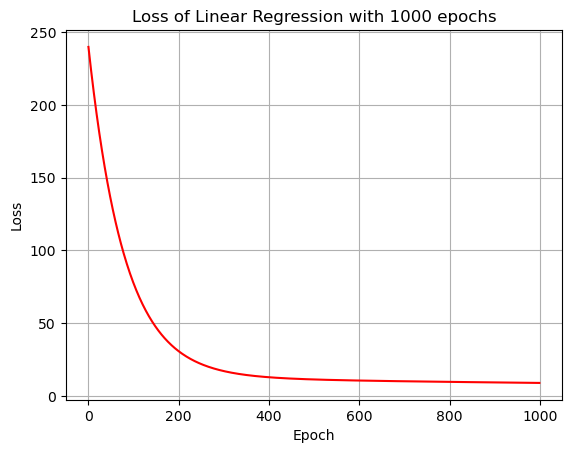

In [38]:
# Vẽ đồ thị Loss của mô hình sau khi đã huấn luyên 100 epoch
plt.plot(rg.Losses,'r')
plt.title(f"Loss of Linear Regression with {rg.epochs} epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()